<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Internship%20Projects/confusion_matriks/confusion_matriks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

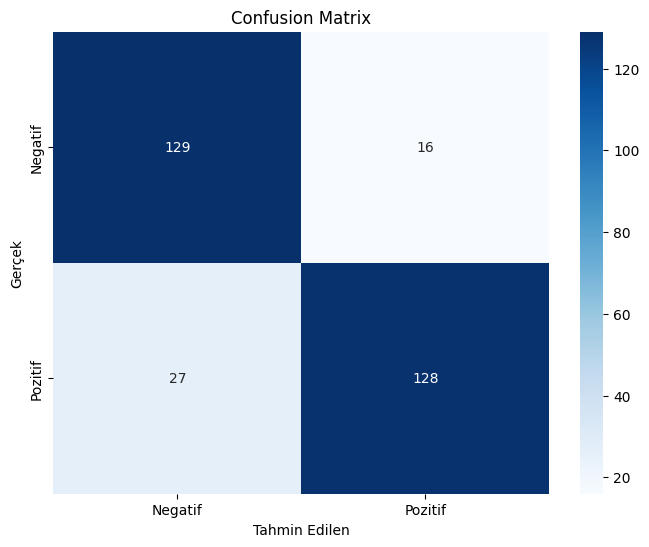

accuracy: 0.857
precision: 0.889
recall: 0.826
specificity: 0.890
f1_score: 0.856


In [17]:
class ConfusionMatrixAnalyzer:
    def __init__(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred
        self.cm = confusion_matrix(y_true, y_pred)

    def get_metrics(self):
        if self.cm.shape == (2, 2):
            tn, fp, fn, tp = self.cm.ravel()

            metrics = {
                'accuracy': (tp + tn) / (tp + tn + fp + fn),
                'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
                'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
                'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
                'f1_score': 0,
                'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
            }

            if metrics['precision'] + metrics['recall'] > 0:
                metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / \
                                    (metrics['precision'] + metrics['recall'])

            return metrics
        else:
            # Çok sınıflı durumda
            return classification_report(self.y_true, self.y_pred, output_dict=True)

    def plot_matrix(self, labels=None):
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=labels, yticklabels=labels)
        plt.title('Confusion Matrix')
        plt.xlabel('Tahmin Edilen')
        plt.ylabel('Gerçek')
        plt.show()

# Kullanım örneği
analyzer = ConfusionMatrixAnalyzer(y_test, y_pred)
metrics = analyzer.get_metrics()
analyzer.plot_matrix(['Negatif', 'Pozitif'])

for metric, value in metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.3f}")